# 01 - The math you actually need

Almost anyone who believes they are "not a maths person" can follow this notebook. A neural network relies on only a handful of small ideas, and each one has a plain-English picture sitting behind the symbols. For every idea you will get the picture first, then a small example worked out by hand, and only then the code.

Here is the whole toolbox, six ideas in total:

- **vectors and matrices**, which are just grids of numbers, and the single operation that matters most: **matrix multiply**
- **the dot product**, a score for how similar two lists of numbers are (this is exactly what attention later uses)
- **broadcasting**, the rule that lets NumPy do arithmetic on grids of different sizes without slow loops
- **softmax**, which turns raw scores into probabilities that add up to 1
- **cross-entropy**, a single number measuring how wrong a guess was
- **gradients and gradient descent**, the method by which a model actually learns

None of this is harder than "multiply some numbers together and add them up." We will build each piece in turn.

In [1]:
import numpy as np
np.random.seed(0)

# Scalars, vectors, matrices, tensors are all just arrays with different numbers of axes.
scalar = np.array(3.0)
vector = np.array([1.0, 2.0, 3.0])
matrix = np.array([[1.0, 2.0, 3.0],
                   [4.0, 5.0, 6.0]])
tensor = np.random.randn(2, 3, 4)   # e.g. (batch, time, features) - the shape we'll use for text

for name, a in [("scalar", scalar), ("vector", vector), ("matrix", matrix), ("tensor", tensor)]:
    print(f"{name:7} shape={a.shape}")

scalar  shape=()
vector  shape=(3,)
matrix  shape=(2, 3)
tensor  shape=(2, 3, 4)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import numpy as np</code>: load NumPy, the toolbox for fast math on grids of numbers, and nickname it <code>np</code> so we can type <code>np.something</code> instead of <code>numpy.something</code>.</li>
<li><code>np.random.seed(0)</code>: fix the random-number generator to a known starting point, so "random" values come out identical every run. That makes the results reproducible.</li>
<li><code>scalar = np.array(3.0)</code>: a <b>scalar</b> is just a single number (here 3.0). No rows, no columns -- one value. (0 axes.)</li>
<li><code>vector = np.array([1.0, 2.0, 3.0])</code>: a <b>vector</b> is a row of numbers, like one line of a spreadsheet. The square brackets make a list. (1 axis.)</li>
<li><code>matrix = np.array([[...], [...]])</code>: a <b>matrix</b> is a grid: rows and columns, like a full spreadsheet. The double brackets mean "a list of rows"; this one is 2 rows &times; 3 columns. (2 axes.)</li>
<li><code>tensor = np.random.randn(2, 3, 4)</code>: a <b>tensor</b> is the general word for a block of numbers with any number of axes. This is a 2&times;3&times;4 block of random values -- picture 2 stacked spreadsheets, each 3 rows by 4 columns. It's exactly the shape we'll use for text (sequences &times; positions &times; features).</li>
<li><code>for name, a in [("scalar", scalar), ...]:</code>: a loop that walks the four items, pairing a label <code>name</code> with the thing itself <code>a</code>, so we can print them the same way.</li>
<li><code>print(f"{name:7} shape={a.shape}")</code>: print each one's name and its <code>.shape</code> (NumPy's "how many along each axis"). <code>:7</code> pads the name to 7 characters so the columns line up. You'll see <code>()</code>, <code>(3,)</code>, <code>(2, 3)</code>, <code>(2, 3, 4)</code>: the axis-counts going up.</li>
</ul>
</details>

## Matrix multiply is the central operation

A **matrix** is simply a grid of numbers arranged in rows and columns. Matrix multiply, written `A @ B` in code, is the operation that almost all of a neural network's work comes down to.

The picture to hold onto: each number in the answer is one row of `A` combined with one column of `B`. You line them up, multiply the matching entries, and add the results. That "multiply matching entries and add them" step is the dot product from the next section, so a matrix multiply is really a whole grid of dot products worked out at once.

The shape rule is `(n, k) @ (k, m) -> (n, m)`. The two inner numbers (the `k` values) must be equal, because they are the length of the lists being dotted together; they cancel, leaving as many rows as `A` had and as many columns as `B` had.

Worked by hand, the entry `C[0,1]` is row 0 of `A` dotted with column 1 of `B`. Row 0 of `A` is `[1, 2, 3]` and column 1 of `B` is `[0, 1, 1]`, so the result is `1*0 + 2*1 + 3*1 = 5`. The code confirms it.

In [2]:
A = np.array([[1., 2., 3.],
              [4., 5., 6.]])      # (2, 3)
B = np.array([[1., 0.],
              [0., 1.],
              [1., 1.]])          # (3, 2)
C = A @ B                          # (2, 2)
print("A", A.shape, "@ B", B.shape, "-> C", C.shape)
print(C)

# C[0,1] is row 0 of A dotted with column 1 of B:
print("check C[0,1] =", float(np.dot(A[0], B[:, 1])))

A (2, 3) @ B (3, 2) -> C (2, 2)
[[ 4.  5.]
 [10. 11.]]
check C[0,1] = 5.0


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>A = np.array([[1., 2., 3.], [4., 5., 6.]])</code>: a 2-row, 3-column grid. The dot in <code>1.</code> just means "treat it as a decimal," not a whole number.</li>
<li><code>B = np.array([[1., 0.], [0., 1.], [1., 1.]])</code>: a 3-row, 2-column grid.</li>
<li><code>C = A @ B</code>: the star of the show: <code>@</code> is <b>matrix multiply</b>. NumPy checks the shapes line up ((2,3) and (3,2) share the inner 3) and produces a (2,2) grid. Each output number is one row of A blended with one column of B.</li>
<li><code>print("A", A.shape, ...)</code>: print the shapes so you can watch (2,3) @ (3,2) collapse to (2,2).</li>
<li><code>A[0]</code>: grab row 0 of A (counting starts at 0), i.e. <code>[1., 2., 3.]</code>.</li>
<li><code>B[:, 1]</code>: grab column 1 of B: the <code>:</code> means "every row," the <code>1</code> picks the second column.</li>
<li><code>np.dot(A[0], B[:, 1])</code>: the dot product of that row and column: multiply matching slots, add them up. We print it to prove it equals <code>C[0,1]</code>: a matrix multiply really is a grid of dot products.</li>
<li><code>float(...)</code>: unwrap NumPy's one-number result into a plain Python number so it prints cleanly.</li>
</ul>
</details>

## The dot product: a measure of similarity

Take two lists of numbers of the same length, multiply them entry by entry, and add up the results. That single number is the **dot product**.

The picture: think of each list as an arrow. The dot product is large and positive when the two arrows point in much the same direction, near zero when they are at right angles (that is, unrelated), and negative when they point in opposite directions. In other words, it is a similarity score that answers "how aligned are these two?"

Worked by hand:
- `[1, 0] . [0.9, 0.1] = 1*0.9 + 0*0.1 = 0.9`. Both arrows point mostly to the right, so the score is large and positive: they are similar.
- `[1, 0] . [0, 1] = 1*0 + 0*1 = 0`. One points right and the other straight up, a right angle, so the score is zero: they are unrelated.

This is the heart of attention. A token works out which earlier tokens are relevant to it by taking dot products with them, and then leans on the ones that score highly. (The `cosine` function below is just the dot product rescaled to ignore the length of the arrows, so its value always falls between -1 and 1.)

In [3]:
def cosine(u, v):
    return float(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))

a = np.array([1., 0.])
b = np.array([0.9, 0.1])   # similar direction to a
c = np.array([0., 1.])     # orthogonal to a
print("a . b =", round(float(a @ b), 2), " cosine:", round(cosine(a, b), 2), "-> similar")
print("a . c =", round(float(a @ c), 2), " cosine:", round(cosine(a, c), 2), "-> unrelated")

a . b = 0.9  cosine: 0.99 -> similar
a . c = 0.0  cosine: 0.0 -> unrelated


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def cosine(u, v):</code>: define a small reusable function that takes two vectors and returns how aligned they are.</li>
<li><code>u @ v</code>: for two flat vectors, <code>@</code> is just the dot product: multiply matching slots and sum.</li>
<li><code>np.linalg.norm(u)</code>: the length of vector <code>u</code> (how long the arrow is). Dividing the dot product by both lengths strips out size and leaves pure <i>direction agreement</i>: that's the cosine, always between -1 and 1.</li>
<li><code>a = np.array([1., 0.])</code>: an arrow pointing right (along the x-axis).</li>
<li><code>b = np.array([0.9, 0.1])</code>: an arrow pointing almost the same way as <code>a</code>.</li>
<li><code>c = np.array([0., 1.])</code>: an arrow pointing straight up -- a right angle to <code>a</code>.</li>
<li><code>round(float(a @ b), 2)</code>: compute the dot product, unwrap it, round to 2 decimals. <code>a&middot;b</code> is large (similar directions); <code>a&middot;c</code> is 0 (unrelated).</li>
</ul>
</details>

## Broadcasting: reuse one row everywhere, without a loop

Often two grids are not the same size. Suppose you have a 3-by-4 grid and want to add the same four numbers to each of its three rows. Rather than writing a loop, NumPy handles this by **broadcasting**: it quietly treats the smaller item (here the list of four numbers) as if it were repeated across the missing rows. Nothing is actually copied, so it stays fast; it is only bookkeeping.

The picture is a single set of settings applied to every row at once, like turning the same four dials on every sample. This comes up constantly, for example when adding a fixed set of numbers (called a **bias**) to every row, or rescaling every column. In the code below, the list `[10, 20, 30, 40]` is added to each of the three rows.

In [4]:
X = np.ones((3, 4))          # 3 rows, 4 features
bias = np.array([10., 20., 30., 40.])   # one value per feature
print((X + bias))            # bias is added to every row, no loop needed
print("shapes:", X.shape, "+", bias.shape, "->", (X + bias).shape)

[[11. 21. 31. 41.]
 [11. 21. 31. 41.]
 [11. 21. 31. 41.]]
shapes: (3, 4) + (4,) -> (3, 4)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>X = np.ones((3, 4))</code>: a 3-row, 4-column grid filled entirely with 1s. (The size is passed as one pair <code>(3, 4)</code>.)</li>
<li><code>bias = np.array([10., 20., 30., 40.])</code>: a single row of 4 numbers, one per column.</li>
<li><code>X + bias</code>: the shapes don't match ((3,4) vs just (4,)), so NumPy <b>broadcasts</b>: it quietly reuses those 4 bias numbers on every one of the 3 rows. You wrote no loop, and none runs -- it's just bookkeeping.</li>
<li><code>print((X + bias).shape)</code>: confirms the result is still (3, 4): same grid, each row shifted by the bias.</li>
</ul>
</details>

## Softmax: turning numbers into probabilities

A model produces raw scores called **logits**, which can be any real numbers, such as `2.0, 1.0, 0.1, -1.0`. We need to convert these into **probabilities**: values that are all positive and add up to 1 (that is, to 100%). Converting scores into probabilities is the whole job of softmax.

$$\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

Reading the formula slowly: $e^{x_i}$ means the fixed number $e$ (about 2.718) raised to the power of score $i$. The symbol $\sum_j$ (a capital Greek letter sigma) is shorthand for "add the following up over every score $j$." So each output is one score's $e$-value divided by the total of all the $e$-values, which is precisely a share of the whole; and a share of the whole is what a probability is.

Why use $e$ at all? It does two useful things at once. It makes every value positive, so there are no negative probabilities, and it widens the gaps, so a clearly higher score ends up with a clearly larger share.

Worked by hand for `[2.0, 1.0, 0.1, -1.0]`: the $e$-values are about `7.39, 2.72, 1.11, 0.37`, which add up to `11.58`. Dividing each by `11.58` gives `0.64, 0.24, 0.10, 0.03`, all positive and summing to 1. The top score of 2.0 ends up with 64% of the total.

(The line `x - x.max()` in the code is a safety step. Subtracting the same number from every score does not change the result, but it stops $e$ raised to a large power from producing a number too big for the computer to handle.)

In [5]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)   # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

logits = np.array([2.0, 1.0, 0.1, -1.0])
p = softmax(logits)
print("probs :", np.round(p, 3))
print("sum   :", round(float(p.sum()), 6), "(always 1)")

probs : [0.638 0.235 0.095 0.032]
sum   : 1.0 (always 1)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def softmax(x, axis=-1):</code>: define softmax. <code>axis=-1</code> is a default: "if the caller doesn't say otherwise, work along the <i>last</i> axis" (across each row of scores).</li>
<li><code>x = x - x.max(axis=axis, keepdims=True)</code>: subtract the biggest score from every score. This doesn't change the final answer, but it stops <code>exp</code> of a big number from overflowing. <code>keepdims=True</code> keeps the shape so the subtraction broadcasts cleanly.</li>
<li><code>e = np.exp(x)</code>: raise <code>e</code> (~2.718) to each score, all at once. This makes everything positive and exaggerates the gaps.</li>
<li><code>return e / e.sum(...)</code>: divide each value by the total of all of them, so the results add up to 1: a share of the whole, which is exactly a probability.</li>
<li><code>logits = np.array([2.0, 1.0, 0.1, -1.0])</code>: four raw scores to feed in.</li>
<li><code>np.round(p, 3)</code> / <code>p.sum()</code>: print the probabilities and their sum, which is always 1. <code>np.round</code> trims only the <i>display</i> to three decimals; <code>p</code> itself keeps every digit it had.</li>
</ul>
</details>

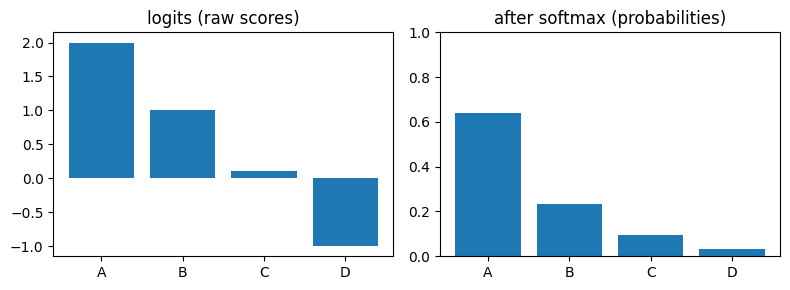

In [6]:
import matplotlib.pyplot as plt
labels = ["A", "B", "C", "D"]
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].bar(labels, logits);  ax[0].set_title("logits (raw scores)")
ax[1].bar(labels, p);       ax[1].set_title("after softmax (probabilities)")
ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import matplotlib.pyplot as plt</code>: load the plotting toolbox, nicknamed <code>plt</code>.</li>
<li><code>fig, ax = plt.subplots(1, 2, figsize=(8, 3))</code>: make a figure with 1 row of 2 side-by-side panels; <code>ax[0]</code> is the left panel, <code>ax[1]</code> the right.</li>
<li><code>ax[0].bar(labels, logits)</code>: a bar chart on the left: one bar per label, heights = the raw logits.</li>
<li><code>ax[1].bar(labels, p)</code>: the same labels on the right, but heights = the softmax probabilities.</li>
<li><code>ax[1].set_ylim(0, 1)</code>: pin the right axis to 0..1, the range probabilities live in.</li>
<li><code>plt.tight_layout(); plt.show()</code>: tidy the spacing and display. The two panels let you see raw scores become probabilities.</li>
</ul>
</details>

## Cross-entropy: how wrong was the guess?

The model gives a probability to every possible next token, and reality then reveals the one token that was actually correct. **Cross-entropy** turns that into a single number, and it looks only at the probability the model gave to the correct answer:

$$\text{loss} = -\log p_{\text{correct}}$$

The picture is the model's *surprise*. If it gave the correct token a probability of 99%, it had essentially predicted it, so the loss is tiny. If it gave the correct token only 1%, it was caught out, so the loss is large. Training amounts to making the model less surprised by the truth, over and over.

Why the $-\log$, the negative logarithm? A logarithm answers the question "what power must I raise a fixed base number to?", and the key fact here is that $\log(1) = 0$, so a perfect 100% guess costs nothing. As the probability falls towards 0 the logarithm becomes a larger and larger negative number, and the minus sign in front turns that into a larger and larger positive loss. So a confident and correct guess is cheap, a confident but wrong guess is expensive, and everything in between sits smoothly on that scale.

Worked by hand with logits `[2.0, 1.0, 0.1, -1.0]` (which softmax turned into `0.64, 0.24, 0.10, 0.03`):
- if the correct token is number 0 (probability 0.64), the loss is `-log(0.64)`, about `0.45`: small, because it was right.
- if the correct token is number 3 (probability 0.03), the loss is `-log(0.03)`, about `3.45`: large, because it was confidently wrong.

That single number is the entire training signal used throughout the course.

In [7]:
def cross_entropy(logits, target_idx):
    p = softmax(logits)
    return -np.log(p[target_idx])

logits = np.array([2.0, 1.0, 0.1, -1.0])   # model likes token 0 most
print("loss if correct token is 0 (confident, right):", round(float(cross_entropy(logits, 0)), 3))
print("loss if correct token is 3 (confident, wrong):", round(float(cross_entropy(logits, 3)), 3))

loss if correct token is 0 (confident, right): 0.449
loss if correct token is 3 (confident, wrong): 3.449


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def cross_entropy(logits, target_idx):</code>: define the loss. It takes the raw scores and the <i>position</i> of the correct answer.</li>
<li><code>p = softmax(logits)</code>: reuse the function from above: scores become probabilities.</li>
<li><code>return -np.log(p[target_idx])</code>: pick out the probability the model gave the <i>correct</i> token, then take its negative log: near 0 when that probability is high, large when it's small. That single number is the loss.</li>
<li><code>cross_entropy(logits, 0)</code>: the correct answer is token 0, the model's favorite &rarr; small loss (confident and right).</li>
<li><code>cross_entropy(logits, 3)</code>: the correct answer is token 3, the model's least favorite &rarr; big loss (confident and wrong).</li>
</ul>
</details>

## Gradients and gradient descent: how it learns

This is the method that drives every model in the course, so it is worth seeing in full.

An analogy. Imagine standing on a hillside in thick fog, trying to reach the lowest point. You cannot see, but you can feel which way the ground slopes under your feet. So you take a small step downhill, feel again, and step again. Repeat this enough times and you arrive at the bottom. That is gradient descent.

- the **loss** is your height on the hill, and we want it low,
- the **gradient** is the slope under your feet, telling you which way is uphill and how steep it is,
- a **step** nudges the model's numbers a little in the downhill direction, which is the direction opposite the gradient.

A function we can picture easily is $f(x) = x^2$, a smooth bowl shape with its lowest point at $x = 0$. Its slope at any point is given by the formula $f'(x) = 2x$ (this slope formula is called the *derivative*). At $x = 8$ the slope is $2 \times 8 = 16$: steep, and tilting upward to the right, so downhill is to the left.

One step worked by hand, using a step size (called the **learning rate**) of `0.1`. The rule is: new x = old x minus learning rate times slope, which gives `8 - 0.1 * 16 = 6.4`. Starting again from `6.4`, the slope is `12.8`, so the next point is `6.4 - 0.1 * 12.8 = 5.12`, then `4.096`, and so on. Each step lands at `0.8` times the previous value, marching steadily towards 0. After 40 steps it has essentially arrived (about `0.00106`).

The learning rate is the size of each step, and the choice matters. Too large, and you leap straight over the bottom and bounce out of the valley, so the loss grows instead of shrinking; too small, and you inch along and take far too long to arrive. A value of `0.1` is a comfortable stride for this example.

The code also shows a *numerical* way to find the slope, so you need not take the calculus on trust. Nudge `x` by a tiny amount each way, measure how much `f` rises or falls, and divide the rise by the distance covered; that ratio is the slope, the same `16` the formula gives. That is all the function `grad_numerical` does. In a real network the computer works out these slopes automatically, which is the subject of notebook 04.

In [8]:
def f(x):  return x**2
def grad_numerical(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2*h)    # slope of a tiny secant line

x = 8.0           # start far from the minimum
lr = 0.1          # learning rate: how big a step we take
history = [x]
for step in range(40):
    g = grad_numerical(f, x)        # which way is downhill (and how steep)
    x = x - lr * g                  # step downhill
    history.append(x)
print("started at 8.0, ended at x =", round(x, 5), " (true minimum is 0)")
print("numerical grad at x=8 was", round(grad_numerical(f, 8.0), 4), " (exact 2*8 = 16)")

started at 8.0, ended at x = 0.00106  (true minimum is 0)
numerical grad at x=8 was 16.0  (exact 2*8 = 16)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def f(x): return x**2</code>: the bowl-shaped function to minimize. <code>**</code> means "to the power of," so this is x&sup2;, lowest at x=0.</li>
<li><code>def grad_numerical(f, x, h=1e-5):</code>: estimate the slope without calculus.</li>
<li><code>(f(x + h) - f(x - h)) / (2*h)</code>: nudge x a hair (<code>1e-5</code> = 0.00001) each way, see how much <code>f</code> rises, divide by the distance: that's rise-over-run, the slope.</li>
<li><code>x = 8.0</code>: start far from the bottom.</li>
<li><code>lr = 0.1</code>: the learning rate: how big a step we take each time.</li>
<li><code>history = [x]</code>: a list recording every position visited (so the next cell can draw the path). <code>history.append(x)</code> adds each new spot to the end.</li>
<li><code>for step in range(40):</code>: repeat 40 times.</li>
<li><code>g = grad_numerical(f, x)</code>: measure the downhill direction and steepness at the current x.</li>
<li><code>x = x - lr * g</code>: step <i>against</i> the slope (downhill). The right side is computed first, then stored back in x.</li>
<li><code>round(x, 5)</code>: after 40 steps x has marched from 8.0 to nearly 0, the minimum.</li>
</ul>
</details>

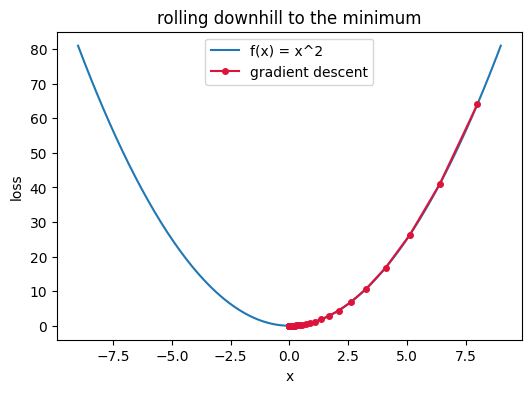

In [9]:
import matplotlib.pyplot as plt
xs = np.linspace(-9, 9, 200)
plt.figure(figsize=(6, 4))
plt.plot(xs, f(xs), label="f(x) = x^2")
plt.plot(history, [f(v) for v in history], "o-", color="crimson", ms=4, label="gradient descent")
plt.legend(); plt.title("rolling downhill to the minimum"); plt.xlabel("x"); plt.ylabel("loss")
plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import matplotlib.pyplot as plt</code>: the plotting toolbox (numpy is already imported earlier in the notebook).</li>
<li><code>np.linspace(-9, 9, 200)</code>: 200 evenly spaced x-values from -9 to 9, for drawing a smooth curve.</li>
<li><code>plt.plot(xs, f(xs))</code>: draw the bowl itself; <code>f(xs)</code> squares all 200 values at once.</li>
<li><code>plt.plot(history, [f(v) for v in history], "o-", ...)</code>: draw the path descent took. <code>[f(v) for v in history]</code> computes the height at each visited x; <code>"o-"</code> means dots joined by lines.</li>
<li><code>plt.legend(); plt.show()</code>: show the labels and render -- you see the red dots rolling down into the valley.</li>
</ul>
</details>

## Recap

The whole toolbox, in plain words:

- **matrix multiply**: combine rows and columns (a whole grid of dot products at once)
- **dot product**: one number for "how aligned, or similar, are these two lists?"
- **broadcasting**: apply one small list to every row, without a loop
- **softmax**: turn raw scores into probabilities that add up to 1
- **cross-entropy**: one number for "how surprised was the model by the truth?"
- **gradient descent**: feel the downhill slope, take a step, and repeat until the loss is low

That really is the maths you need. Everything more advanced later in the course is built out of these six ideas.

Next, notebook 02 turns raw text into the numbers a model can actually work with.